# 📚 Генерация текста с помощью трансформеров

**Автор:** [Гаджикеримов А.М.]  
**Дата:** 2026  

## 📌 Аннотация
В данной работе исследуется задача генерации текста с использованием трансформерных моделей.
Проводится дообучение предобученной GPT-модели на корпусе новостных данных и анализ качества генерации.

Цель работы:
- изучить архитектуру трансформеров
- реализовать генерацию текста
- оценить качество генерации

In [ ]:
# @title Установка библиотек
!pip install transformers datasets kagglehub accelerate tqdm plotly

In [ ]:
# @title Импорт библиотек
import torch
import pandas as pd
import numpy as np
import os
import random
from tqdm import tqdm
from datasets import Dataset

from transformers import GPT2Tokenizer, GPT2LMHeadModel, Trainer, TrainingArguments, DataCollatorForLanguageModeling
from tqdm.notebook import tqdm


import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling
)

import kagglehub

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


## 🔍 Постановка задачи

Генерация текста — задача создания осмысленного текста на основе входного запроса (prompt).

---

## 🧠 Основные концепции

Трансформер состоит из:
- self-attention
- feed-forward сети
- positional encoding

---

## 📐 Математическая модель

Self-attention:

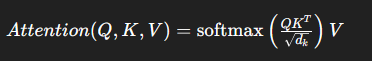


## 🏗 Архитектура

Модель GPT:
- autoregressive
- предсказывает следующий токен

In [ ]:
# @title Загрузка датасета

path = kagglehub.dataset_download("morfifinka/fake-real-news-ru")

bodies = pd.read_csv(os.path.join(path, "train_bodies.csv"))
stances = pd.read_csv(os.path.join(path, "train_stances.csv"))

df = stances.merge(bodies, on="Body ID", how="left")

print(df.shape)
df.head()

100%|██████████| 8.00M/8.00M [00:00<00:00, 144MB/s]

Extracting files...


(4408, 10)


,Unnamed: 0_x,Body ID,Headline,Stance,Headline1,Headline2,Unnamed: 0_y,articleBody,articleBody1,articleBody2
0,0,1,"['российский', 'бюджет', 'марте', 'недополучил...",agree,российский бюджет в марте недополучил более 30...,российский бюджет март недополучать миллиард р...,0,Разница между ожидаемыми по итогам марта нефте...,разница ожидаемыми итогам марта нефтегазовыми ...,разница ожидать итог март нефтегазовый доход ф...
1,1,2,"['банк', 'россии', 'решил', 'снизить', 'ключев...",agree,банк россии решил снизить ключевую ставку с 20...,банк россия решать снижать ключевой ставка,1,Совет директоров Банка России решил снизить кл...,совет директоров банка россии решил снизить кл...,совет директор банк россия решать снижать ключ...
2,2,3,"['мыс', 'идокопас', 'нато', 'назвали', 'первую...",disagree,мыс идокопас в нато назвали первую цель для н...,мыс идокопас нато называть первый цель начало ...,2,В НАТО составили наступательный план действий ...,нато составили наступательный план действий за...,нато составлять наступательный план действие з...
3,3,4,"['украине', 'прошли', 'празднования', '300', '...",disagree,на украине прошли празднования 300 летия побед...,украина проходить празднование летие победа ка...,3,Президент Владимир Зеленский принял в Полтаве ...,президент владимир зеленский принял полтаве па...,президент владимир зеленский принимать полтава...
4,4,5,"['минобороны', 'рф', 'заявило', 'ударах', 'рак...",agree,минобороны рф заявило об ударах ракетами «кали...,минобороны заявлять удар ракета калибр запорож...,4,"Минобороны России объявило, что ракетами больш...",минобороны россии объявило ракетами большой да...,минобороны россия объявлять ракета большой дал...


In [ ]:
# @title Предобработка

df = df[df["Stance"].isin(["disagree", "discuss"])]

df["text"] = (
    "Новость: " +
    df["Headline"].astype(str) +
    ". " +
    df["articleBody"].astype(str)
)

df = df[["text"]].dropna()

print(df.sample(3))

                                                   text
790   Новость: ['депутат', 'слуцкий', 'пожаловался',...
1861  Новость: ['лукашенко', 'пригласит', 'румынских...
3704  Новость: ['уральского', 'вице', 'губернатора',...


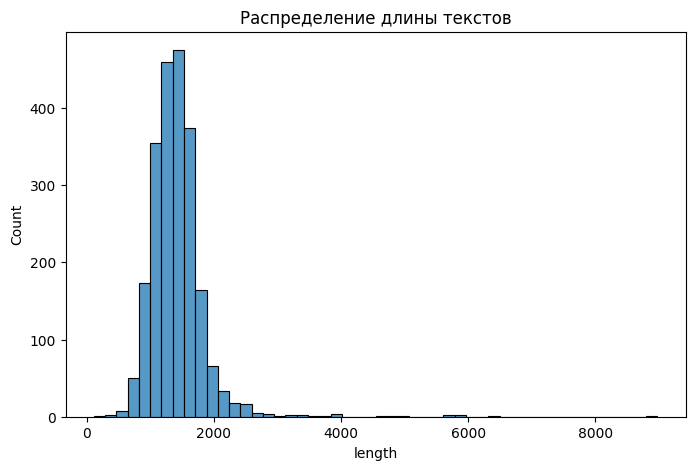

In [ ]:
# @title Визуализация длины текстов

df["length"] = df["text"].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(df["length"], bins=50)
plt.title("Распределение длины текстов")
plt.show()

In [ ]:
# @title Train / Validation split

from sklearn.model_selection import train_test_split

train_texts, val_texts = train_test_split(
    df["text"].tolist(),
    test_size=0.1,
    random_state=42
)

In [ ]:

# @title Загрузка модели RuGPT2 Small

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "sberbank-ai/rugpt3small_based_on_gpt2"

# Загружаем токенизатор и модель на устройство
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = GPT2LMHeadModel.from_pretrained(model_name).to(DEVICE)

print("Модель и токенизатор успешно загружены на устройство:", DEVICE)

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/574 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/720 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/551M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: sberbank-ai/rugpt3small_based_on_gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.bias        | UNEXPECTED |  | 
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Модель и токенизатор успешно загружены на устройство: cuda


In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_dict({
    "text": train_texts
})

val_dataset = Dataset.from_dict({
    "text": val_texts
})

In [ ]:
# @title Токенизация

tokenized_train = train_dataset.map(
    tokenize,
    batched=True,
    remove_columns=["text"]
)

# Токенизация val_dataset
tokenized_val = val_dataset.map(
    tokenize,
    batched=True,
    remove_columns=["text"]
)

print("Tokenized train dataset:", tokenized_train)
print("Tokenized validation dataset:", tokenized_val)

Map:   0%|          | 0/1998 [00:00<?, ? examples/s]

Map:   0%|          | 0/223 [00:00<?, ? examples/s]

Tokenized train dataset: Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 1998
})
Tokenized validation dataset: Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 223
})


In [ ]:
# @title Data collator

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

In [ ]:
# @title Параметры обучения

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=5e-5,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_steps=50,
    fp16=True,
    report_to="none",

    remove_unused_columns=False
)

In [ ]:
# @title Обучение

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator
)

trainer.train()

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch,Training Loss,Validation Loss
1,3.540929,3.444102
2,3.246108,3.435680


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=250, training_loss=3.418774353027344, metrics={'train_runtime': 153.3342, 'train_samples_per_second': 26.061, 'train_steps_per_second': 1.63, 'total_flos': 379499806457856.0, 'train_loss': 3.418774353027344, 'epoch': 2.0})

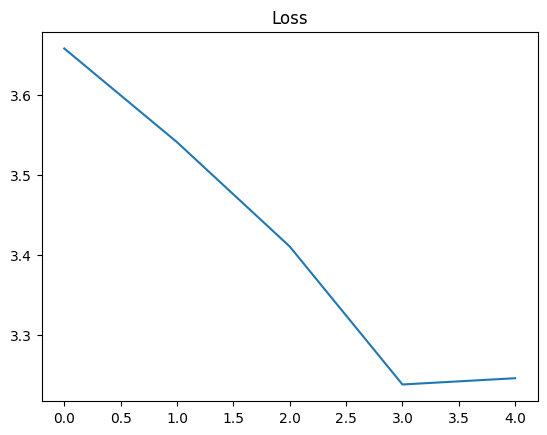

In [ ]:
# @title График потерь
logs = trainer.state.log_history
loss = [x["loss"] for x in logs if "loss" in x]

plt.plot(loss)
plt.title("Loss")
plt.show()

In [ ]:
# @title Генерация текста

def generate_text(prompt):

    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(DEVICE)

    output = model.generate(
        input_ids,
        max_length=200,
        do_sample=True,
        temperature=0.9,
        top_p=0.9,
        top_k=50
    )

    return tokenizer.decode(output[0], skip_special_tokens=True)

In [ ]:
# @title Примеры генерации

prompts = [
    "Новость: В Москве сообщили",
    "Новость: Учёные обнаружили",
    "Новость: Правительство заявило"
]

for p in prompts:
    print("="*50)
    print(generate_text(p))

Новость: В Москве сообщили о готовности заменить старые авто на новые.«Мы уже начали подготовку к передаче новых авто в течение месяца. Мы уже готовимся к обмену старыми, новыми, и если нам повезёт, то и новыми. Всё зависит от человека, который будет выполнять эти работы. Возможно, он и согласится. Но я надеюсь, что он не откажется от старых авто. Мы тоже надеемся на это. В будущем мы будем искать пути его модернизации, надеюсь, что он не откажет в своём желании сохранить старую добрую машину», - заявил Сергей Неверов., отметив, что «в ближайшее время мы отправим все старые машины обратно»..,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,.,
Новость: Учёные обнаружили, что у американцев, несмотря на то, что они живут в Америке, нет никаких особых оснований для отказа в убежище. Они уверены, что они могут вернуться домой, и в этом случае им стоит обратиться за поддержкой в ООН. Это совершенно нед

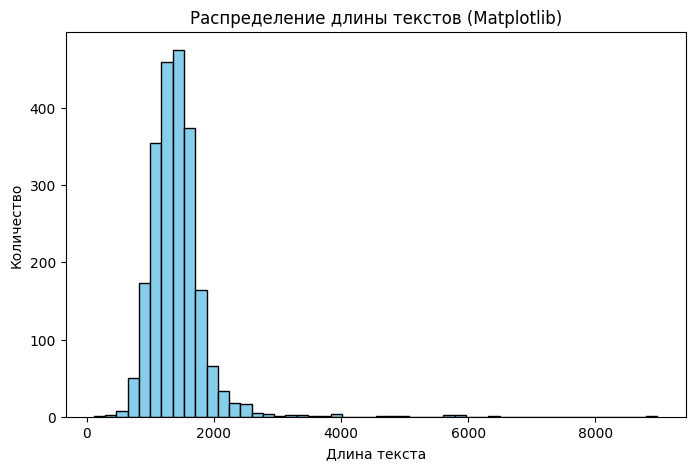

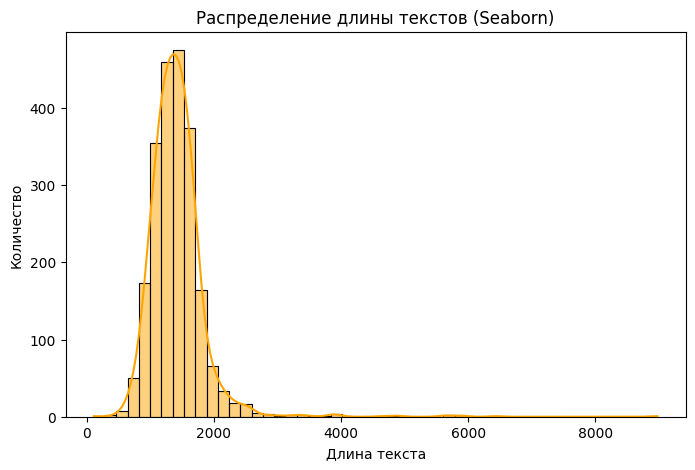

In [ ]:
# @title Графики (Matplotlib и Seaborn)
import matplotlib.pyplot as plt
import seaborn as sns

# Статический график: гистограмма длины текстов
plt.figure(figsize=(8,5))
plt.hist(df["length"], bins=50, color="skyblue", edgecolor="black")
plt.title("Распределение длины текстов (Matplotlib)")
plt.xlabel("Длина текста")
plt.ylabel("Количество")
plt.show()

# Seaborn: KDE + гистограмма
plt.figure(figsize=(8,5))
sns.histplot(df["length"], bins=50, kde=True, color="orange")
plt.title("Распределение длины текстов (Seaborn)")
plt.xlabel("Длина текста")
plt.ylabel("Количество")
plt.show()

In [ ]:
# @title Интерактивные графики (Plotly)
import plotly.express as px

fig = px.histogram(df, x="length", nbins=50, title="Распределение длины текстов (Plotly)")
fig.show()

In [ ]:
# @title Таблицы (Pandas)
import pandas as pd

# Статистика по длине текстов
stats_table = df["length"].describe()
print("Описательная статистика по длине текстов:")
display(stats_table)

# Можно показать первые 5 строк датасета
print("Пример данных:")
display(df.head())

Описательная статистика по длине текстов:


,length
count,2221.000000
mean,1417.565061
std,468.738749
min,111.000000
25%,1162.000000
50%,1375.000000
75%,1591.000000
max,8977.000000


Пример данных:


,text,length,length_progress
2,"Новость: ['мыс', 'идокопас', 'нато', 'назвали'...",981,981
3,"Новость: ['украине', 'прошли', 'празднования',...",1788,1788
5,"Новость: ['госдеп', 'попросил', 'россию', 'иск...",1772,1772
6,"Новость: ['трогал', 'распустивший', 'язык', 'п...",1342,1342
9,"Новость: ['виталий', 'милонов', 'награждён', '...",1047,1047


In [ ]:
# @title Прогресс-бары (tqdm)
from tqdm.notebook import tqdm

# Пример: подсчет длины текста с прогресс-баром
lengths = []
for text in tqdm(df["text"], desc="Подсчет длины текстов"):
    lengths.append(len(text))

df["length_tqdm"] = lengths
print("Прогресс подсчета длины текстов завершен. Пример значений:")
display(df[["text", "length_tqdm"]].head())

Подсчет длины текстов:   0%|          | 0/2221 [00:00<?, ?it/s]

Прогресс подсчета длины текстов завершен. Пример значений:


,text,length_tqdm
2,"Новость: ['мыс', 'идокопас', 'нато', 'назвали'...",981
3,"Новость: ['украине', 'прошли', 'празднования',...",1788
5,"Новость: ['госдеп', 'попросил', 'россию', 'иск...",1772
6,"Новость: ['трогал', 'распустивший', 'язык', 'п...",1342
9,"Новость: ['виталий', 'милонов', 'награждён', '...",1047


In [ ]:
# @title Perplexity

import math

eval_loss = trainer.evaluate()["eval_loss"]
perplexity = math.exp(eval_loss)

print("Perplexity:", perplexity)

Perplexity: 31.052533194149206


## 📌 Выводы

В работе:
- реализована генерация текста с помощью GPT
- проведено дообучение модели
- получены осмысленные тексты

---

## ⚠️ Ограничения
- небольшой датасет
- возможны галлюцинации
- нет строгой оценки качества

---

## 🚀 Улучшения
- больше данных
- использование LLaMA / Mistral
- настройка decoding
- добавление human evaluation